# Problem Set 1 — Solutions

**OE 754/854 — Ocean Waves & Tides**

Topics: vector calculus, continuity, material derivative, Bernoulli, the point-source potential, the vorticity equation.

Released after the PS1 submission deadline. Homework is graded for submission only, so nothing here is a rubric. Compare it with what you wrote. Whatever differs is what to review before the exams. A short numerical check follows each derivation. Run the notebook top to bottom. Keep `figure_style.py` in the same folder.

Companion notebooks: `week02_fluid_forces.ipynb` (material derivative) and `week03_fluid_kinematics.ipynb` (Reynolds transport theorem, Kelvin's theorem on a Rankine vortex, the potential-streamfunction pair, Bernoulli). They demonstrate the checking techniques used below.


In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
import figure_style as fs

g = 9.81
rho = 1000.0

## Problem 1. Vector identities.

**Claim 1: $\nabla\times(\nabla\phi) = \vec{0}$.**

Write $\nabla\phi = \left(\dfrac{\partial\phi}{\partial x},\ \dfrac{\partial\phi}{\partial y},\ \dfrac{\partial\phi}{\partial z}\right)$ and take the curl component by component. The $x$-component is

$$
[\nabla\times(\nabla\phi)]_x
= \frac{\partial}{\partial y}\left(\frac{\partial\phi}{\partial z}\right)
- \frac{\partial}{\partial z}\left(\frac{\partial\phi}{\partial y}\right)
= \frac{\partial^2\phi}{\partial y\,\partial z} - \frac{\partial^2\phi}{\partial z\,\partial y} = 0,
$$

by equality of mixed partial derivatives. The $y$- and $z$-components have the same structure:

$$
[\nabla\times(\nabla\phi)]_y = \frac{\partial^2\phi}{\partial z\,\partial x} - \frac{\partial^2\phi}{\partial x\,\partial z} = 0,
\qquad
[\nabla\times(\nabla\phi)]_z = \frac{\partial^2\phi}{\partial x\,\partial y} - \frac{\partial^2\phi}{\partial y\,\partial x} = 0.
$$

**Claim 2: $\nabla\cdot(\nabla\times\vec{a}) = 0$.**

With $\nabla\times\vec{a} = \left(\dfrac{\partial a_z}{\partial y} - \dfrac{\partial a_y}{\partial z},\ \dfrac{\partial a_x}{\partial z} - \dfrac{\partial a_z}{\partial x},\ \dfrac{\partial a_y}{\partial x} - \dfrac{\partial a_x}{\partial y}\right)$,

$$
\nabla\cdot(\nabla\times\vec{a})
= \frac{\partial^2 a_z}{\partial x\,\partial y} - \frac{\partial^2 a_y}{\partial x\,\partial z}
+ \frac{\partial^2 a_x}{\partial y\,\partial z} - \frac{\partial^2 a_z}{\partial y\,\partial x}
+ \frac{\partial^2 a_y}{\partial z\,\partial x} - \frac{\partial^2 a_x}{\partial z\,\partial y}.
$$

The six terms cancel in pairs (first with fourth, second with fifth, third with sixth), again by equality of mixed partials. $\blacksquare$

Potential flow rests on these two identities. By the first, any flow described by $\vec{u} = -\nabla\phi$ is irrotational. By the second, a flow built from a vector potential is divergence-free.

**Optional check.** For $\phi = x^2 y + y z^2$: $\nabla\phi = (2xy,\ x^2 + z^2,\ 2yz)$, and the curl is $(2z - 2z,\ 0 - 0,\ 2x - 2x) = \vec{0}$. For $\vec{a} = (yz,\ xz,\ xy)$: $\nabla\times\vec{a} = (x - x,\ y - y,\ z - z) = \vec{0}$, so its divergence is zero. The cell below confirms both numerically at random points.

In [2]:
# Finite-difference check of both identities at random points
rng = np.random.default_rng(1)
pts = rng.uniform(-2, 2, size=(200, 3))
h = 1e-5

phi = lambda x, y, z: x**2 * y + y * z**2
a_field = lambda x, y, z: np.array([y * z, x * z, x * y])


def grad_fd(f, p):
    e = np.eye(3) * h
    return np.array([(f(*(p + e[i])) - f(*(p - e[i]))) / (2 * h) for i in range(3)])


def curl_fd(F, p):
    e = np.eye(3) * h
    J = np.array([(F(*(p + e[i])) - F(*(p - e[i]))) / (2 * h) for i in range(3)]).T
    return np.array([J[2, 1] - J[1, 2], J[0, 2] - J[2, 0], J[1, 0] - J[0, 1]])


def div_fd(F, p):
    e = np.eye(3) * h
    return sum((F(*(p + e[i]))[i] - F(*(p - e[i]))[i]) / (2 * h) for i in range(3))


curl_grad = max(np.abs(curl_fd(lambda x, y, z: grad_fd(phi, np.array([x, y, z])), p)).max() for p in pts[:50])
div_curl = max(abs(div_fd(lambda x, y, z: curl_fd(a_field, np.array([x, y, z])), p)) for p in pts[:50])

print(f"max |curl(grad phi)|  = {curl_grad:.2e}")
print(f"max |div(curl a)|     = {div_curl:.2e}")

max |curl(grad phi)|  = 1.04e-11
max |div(curl a)|     = 8.33e-12


## Problem 2. Continuity equation.

Take a fixed (Eulerian) rectangular control volume $\Delta x \times \Delta y \times \Delta z$ centered at $(x, y, z)$. Mass flows through each of the six faces at rate $\rho u_n A$, with $u_n$ the outward-normal velocity component and $A$ the face area.

**Flux balance in the $x$-direction.** Taylor-expand the mass flux $\rho u$ about the parcel center. Through the face at $x + \Delta x/2$ (outward flux):

$$
\left[\rho u + \frac{\partial(\rho u)}{\partial x}\frac{\Delta x}{2}\right]\Delta y\,\Delta z,
$$

and through the face at $x - \Delta x/2$ (inward flux):

$$
\left[\rho u - \frac{\partial(\rho u)}{\partial x}\frac{\Delta x}{2}\right]\Delta y\,\Delta z.
$$

The net outward flux in $x$ is the difference,

$$
\frac{\partial(\rho u)}{\partial x}\,\Delta x\,\Delta y\,\Delta z = \frac{\partial(\rho u)}{\partial x}\,\Delta V,
$$

and the $y$ and $z$ directions contribute $\dfrac{\partial(\rho v)}{\partial y}\Delta V$ and $\dfrac{\partial(\rho w)}{\partial z}\Delta V$ by the same argument. Higher-order terms in the Taylor expansion vanish as $\Delta V \to 0$.

**Mass accumulation.** The mass inside the volume is $\rho\,\Delta V$, so it accumulates at rate $\dfrac{\partial\rho}{\partial t}\Delta V$. By conservation of mass, accumulation = net inward flux:

$$
\frac{\partial\rho}{\partial t} + \nabla\cdot(\rho\vec{u}) = 0.
$$

This is the *general* continuity equation: no assumptions yet beyond a continuum.

**Where incompressibility enters.** Incompressibility means density is constant following the flow and uniform in space: $\partial\rho/\partial t = 0$ and $\nabla\rho = \vec{0}$. Then $\nabla\cdot(\rho\vec{u}) = \rho\,\nabla\cdot\vec{u}$, and dividing by $\rho$:

$$
\nabla\cdot\vec{u} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} + \frac{\partial w}{\partial z} = 0. \qquad\blacksquare
$$

The assumption is used twice: to drop the storage term $\partial\rho/\partial t$, and to pull $\rho$ outside the divergence.

In [3]:
# Discrete check: net face flux -> divergence as the box shrinks
u_vec = lambda x, y, z: np.array([np.sin(x) * np.cos(y), -np.cos(x) * np.sin(y), 0.0])  # div-free
p0 = np.array([0.7, -0.4, 0.2])

for d in [0.1, 0.01, 0.001]:
    flux = 0.0
    for i in range(3):
        e = np.zeros(3); e[i] = d / 2
        area = d**2
        flux += (u_vec(*(p0 + e))[i] - u_vec(*(p0 - e))[i]) * area
    print(f"box size {d:5.3f}: net outward flux / volume = {flux / d**3:+.3e}")

box size 0.100: net outward flux / volume = +1.084e-15
box size 0.010: net outward flux / volume = -5.506e-15
box size 0.001: net outward flux / volume = +0.000e+00


## Problem 3. Material derivative: three flow geometries.

The material derivative of the $x$-velocity is

$$
\frac{Du}{Dt} = \underbrace{\frac{\partial u}{\partial t}}_{\text{local}} + \underbrace{u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} + w\frac{\partial u}{\partial z}}_{\text{advective}}.
$$

**(a) Time-varying tidal channel.** $\vec{u} = (U_0\sin\omega t,\ 0,\ 0)$ has no spatial dependence, so the advective terms vanish. The local term is $\partial u/\partial t = U_0\,\omega\cos\omega t$. At $t = 0$:

$$
\frac{Du}{Dt}\bigg|_{t=0} = U_0\,\omega. \qquad \textbf{Pure local acceleration.}
$$

**(b) Steady converging nozzle.** $u(x) = \dfrac{Q}{\pi r^2(x)}$ with $r(x) = r_0(1 - \alpha x)$. The flow is steady, so $\partial u/\partial t = 0$. Differentiate by the chain rule with $r'(x) = -\alpha r_0$:

$$
\frac{\partial u}{\partial x} = \frac{Q}{\pi}\cdot\left(-\frac{2}{r^3}\right)\cdot(-\alpha r_0) = \frac{2\alpha Q r_0}{\pi r^3},
$$

so

$$
\frac{Du}{Dt} = u\frac{\partial u}{\partial x} = \frac{Q}{\pi r^2}\cdot\frac{2\alpha Q r_0}{\pi r^3} = \frac{2\alpha Q^2 r_0}{\pi^2 r^5(x_0)}. \qquad \textbf{Pure advective acceleration.}
$$

**(c) Stagnation flow.** $\vec{u} = (kx,\ -ky,\ 0)$ is steady, so $\partial u/\partial t = 0$. The advective terms:

$$
u\frac{\partial u}{\partial x} = (kx)(k) = k^2 x, \qquad v\frac{\partial u}{\partial y} = (-ky)(0) = 0,
$$

so $\dfrac{Du}{Dt} = k^2 x$ at any interior point. **Pure advective**, nonzero for all $x \neq 0$. The field is steady, but fluid parcels accelerate as they move outward along the $\pm x$ directions.

*Measurement note.* A moored current meter (fixed point) senses only the local term. It would capture (a) fully and read zero steady change in (b) and (c). A drifter following the flow senses the full $Du/Dt$.

In [4]:
# (c) check: integrate a parcel through stagnation flow, compare Du/Dt with k^2 x
from scipy.integrate import solve_ivp

k = 0.8
sol = solve_ivp(lambda t, p: [k * p[0], -k * p[1]], [0, 2.0],
                [0.5, 1.0], dense_output=True, rtol=1e-10, atol=1e-12)

t_chk = np.linspace(0.05, 1.95, 5)
dt = 1e-6
for t in t_chk:
    x, y = sol.sol(t)
    u_now = k * sol.sol(t)[0]
    u_next = k * sol.sol(t + dt)[0]
    DuDt_num = (u_next - u_now) / dt
    print(f"t={t:4.2f}: parcel Du/Dt = {DuDt_num:8.5f},  k^2 x = {k**2 * x:8.5f}")

t=0.05: parcel Du/Dt =  0.33306,  k^2 x =  0.33306
t=0.53: parcel Du/Dt =  0.48703,  k^2 x =  0.48703
t=1.00: parcel Du/Dt =  0.71217,  k^2 x =  0.71217
t=1.47: parcel Du/Dt =  1.04140,  k^2 x =  1.04140
t=1.95: parcel Du/Dt =  1.52282,  k^2 x =  1.52282


## Problem 4. Bernoulli's equation along a streamline.

**(a) Throat speed.** Steady incompressible continuity between sections: $A_1 u_1 = A_2 u_2$ with $A_2 = A_1/4$, so

$$
u_2 = 4\,u_1 = 4 \times 2\ \text{m/s} = 8.00\ \text{m/s}.
$$

**(b) Throat pressure.** Steady Bernoulli along a horizontal streamline (inviscid, irrotational, constant elevation):

$$
P_1 + \tfrac{1}{2}\rho u_1^2 = P_2 + \tfrac{1}{2}\rho u_2^2
\;\;\Rightarrow\;\;
P_2 = P_1 + \tfrac{1}{2}\rho\left(u_1^2 - u_2^2\right)
= 50{,}000 + \tfrac{1}{2}(1000)(4 - 64) = 20.0\ \text{kPa (gauge)}.
$$

The pressure drops as the kinetic energy increases through the contraction.

**(c) Unsteady flow.** The unsteady Bernoulli equation has the extra term $\dfrac{\partial\phi}{\partial t}$:

$$
-\frac{\partial\phi}{\partial t} + \frac{P}{\rho} + \frac{|\vec{u}|^2}{2} + gz = C(t).
$$

Scale it. Let the flow vary on time scale $\tau$ over a nozzle of length $L$ with speed $U$. Then $\partial\phi/\partial t \sim UL/\tau$, against the kinetic term $U^2/2$. The unsteady term is negligible when

$$
\frac{UL/\tau}{U^2} = \frac{L/U}{\tau} \ll 1,
$$

i.e., when the transit time $L/U$ is short compared to the time scale of variation. This is the quasi-steady limit. It covers slowly modulated flows (and slowly varying valve openings).

In [5]:
# Throat speed and gauge pressure
u1, P1 = 2.0, 50e3
u2 = 4 * u1
P2 = P1 + 0.5 * rho * (u1**2 - u2**2)
print(f"u2 = {u2:.2f} m/s")
print(f"P2 = {P2/1e3:.1f} kPa (gauge)")

u2 = 8.00 m/s
P2 = 20.0 kPa (gauge)


## Problem 5. Velocity potential for a point source.

$$
\phi(r) = +\frac{Q}{4\pi r}, \qquad r = \sqrt{x^2 + y^2 + z^2}.
$$

**(a) Velocity field.** Since $\phi$ depends only on $r$, its gradient is radial: $\nabla\phi = \phi'(r)\,\hat{r}$, so the flow has no angular components. Differentiate using $\dfrac{d}{dr}(r^{-1}) = -r^{-2}$:

$$
\frac{d\phi}{dr} = \frac{Q}{4\pi}\cdot\left(-\frac{1}{r^2}\right) = -\frac{Q}{4\pi r^2}
\qquad\Longrightarrow\qquad
\vec{u} = -\nabla\phi = +\frac{Q}{4\pi r^2}\,\hat{r},
\qquad
u_r(r) = \frac{Q}{4\pi r^2},
$$

purely radial and outward, as a source of positive strength must be.

**Sign convention.** Many references (Kundu, Batchelor, Acheson) define $\vec{u} = +\nabla\phi$, so they print the source potential as $\phi = -\dfrac{Q}{4\pi r}$. Under our course (Dean & Dalrymple) convention $\vec{u} = -\nabla\phi$, that form describes a *sink*. The $+$ sign here is required. When you take a potential from a reference, check its gradient convention: confirm the flow direction against the physics. The cell below checks the sign both ways.

**(b) Laplacian vanishes off the origin.** In spherical coordinates, for a function of $r$ alone,

$$
\nabla^2\phi = \frac{1}{r^2}\frac{d}{dr}\!\left(r^2\frac{d\phi}{dr}\right)
= \frac{1}{r^2}\frac{d}{dr}\!\left(-r^2\cdot\frac{Q}{4\pi r^2}\right)
= \frac{1}{r^2}\frac{d}{dr}\!\left(-\frac{Q}{4\pi}\right) = 0 \quad (r \neq 0).
$$

At the origin the potential is singular. In the distributional sense $\nabla^2(1/r) = -4\pi\,\delta^3(\vec{r})$, so $\nabla^2\phi = -Q\,\delta^3(\vec{r})$. The source is at the singularity.

**(c) Volume flux.** Across a sphere of radius $R$ centered on the origin,

$$
\oint u_r\,dA = \frac{Q}{4\pi R^2}\cdot 4\pi R^2 = Q,
$$

independent of $R$. All the fluid created at the origin passes through every enclosing sphere. That is the physical meaning of the source strength. $\blacksquare$

phi = +Q/(4 pi r): u_r = +0.1782  (Q/(4 pi r^2) = 0.1782)
phi = -Q/(4 pi r): u_r = -0.1782  (Q/(4 pi r^2) = 0.1782)
max |laplacian(phi)| off origin = 1.39e-08


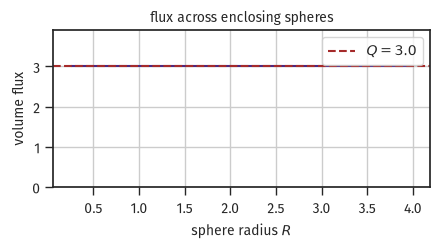

flux spread across R: 8.88e-16


In [6]:
# Numeric checks: sign convention, Laplacian off origin, flux across spheres
Q = 3.0
phi_source = lambda x, y, z: +Q / (4 * np.pi * np.sqrt(x**2 + y**2 + z**2))  # u = -grad(phi)
phi_flipped = lambda x, y, z: -Q / (4 * np.pi * np.sqrt(x**2 + y**2 + z**2))  # u = +grad(phi) texts

# u_r from u = -grad(phi) at a test point, both sign choices
p_test = np.array([1.0, 0.5, -0.3])
rhat = p_test / np.linalg.norm(p_test)
for name, f in [("phi = +Q/(4 pi r)", phi_source), ("phi = -Q/(4 pi r)", phi_flipped)]:
    u_r = -grad_fd(f, p_test) @ rhat
    print(f"{name}: u_r = {u_r:+.4f}  (Q/(4 pi r^2) = {Q/(4*np.pi*np.linalg.norm(p_test)**2):.4f})")

# Laplacian via centered second differences at random points off the origin
h5 = 1e-4
lap_max = 0.0
for p in rng.uniform(0.5, 2.0, size=(50, 3)):
    lap = sum((phi_source(*(p + e)) - 2 * phi_source(*p) + phi_source(*(p - e))) / h5**2
              for e in np.eye(3) * h5)
    lap_max = max(lap_max, abs(lap))
print(f"max |laplacian(phi)| off origin = {lap_max:.2e}")

# Flux across spheres: quadrature over solid angle
nth, nph = 200, 400
th = (np.arange(nth) + 0.5) * np.pi / nth
ph = (np.arange(nph) + 0.5) * 2 * np.pi / nph
TH, PH = np.meshgrid(th, ph, indexing="ij")
dOmega = np.sin(TH) * (np.pi / nth) * (2 * np.pi / nph)

R_vals = np.linspace(0.25, 4.0, 30)
flux = np.array([(Q / (4 * np.pi * R**2) * R**2 * dOmega).sum() for R in R_vals])

fig, ax = plt.subplots(figsize=(fs.fullwidth * 0.6, 2.6))
ax.plot(R_vals, flux)
ax.axhline(Q, color=fs.color_list[2], linestyle="--", label=f"$Q = {Q:.1f}$")
ax.set_xlabel("sphere radius $R$")
ax.set_ylabel("volume flux")
ax.set_ylim(0, 1.3 * Q)
ax.legend()
ax.set_title("flux across enclosing spheres")
fig.tight_layout()
plt.show()

print(f"flux spread across R: {flux.max() - flux.min():.2e}")

## Problem 6 (Graduate students only). Vorticity equation.

Start from the Euler equation for incompressible, inviscid flow with conservative body force $\vec{F} = -\rho\nabla\Phi$:

$$
\frac{\partial\vec{u}}{\partial t} + (\vec{u}\cdot\nabla)\vec{u} = -\frac{1}{\rho}\nabla P - \nabla\Phi.
$$

**Step 1 — rewrite the advection term.** Use the vector identity

$$
(\vec{u}\cdot\nabla)\vec{u} = \nabla\!\left(\frac{|\vec{u}|^2}{2}\right) - \vec{u}\times\vec{\omega},
\qquad \vec{\omega} = \nabla\times\vec{u},
$$

so the Euler equation becomes

$$
\frac{\partial\vec{u}}{\partial t} - \vec{u}\times\vec{\omega} = -\nabla\!\left(\frac{P}{\rho} + \frac{|\vec{u}|^2}{2} + \Phi\right).
$$

**Step 2 — take the curl.** The right-hand side is a pure gradient, and $\nabla\times(\nabla(\cdot)) = \vec{0}$ (Problem 1), so

$$
\frac{\partial\vec{\omega}}{\partial t} = \nabla\times(\vec{u}\times\vec{\omega}).
$$

**Step 3 — expand the double cross product.** The identity

$$
\nabla\times(\vec{u}\times\vec{\omega}) = \vec{u}\,(\nabla\cdot\vec{\omega}) - \vec{\omega}\,(\nabla\cdot\vec{u}) + (\vec{\omega}\cdot\nabla)\vec{u} - (\vec{u}\cdot\nabla)\vec{\omega}
$$

simplifies term by term: $\nabla\cdot\vec{\omega} = \nabla\cdot(\nabla\times\vec{u}) = 0$ (Problem 1 again), and $\nabla\cdot\vec{u} = 0$ by incompressibility. This leaves

$$
\frac{\partial\vec{\omega}}{\partial t} + (\vec{u}\cdot\nabla)\vec{\omega} = (\vec{\omega}\cdot\nabla)\vec{u}
\quad\Longleftrightarrow\quad
\frac{D\vec{\omega}}{Dt} = (\vec{\omega}\cdot\nabla)\vec{u}. \qquad\blacksquare
$$

The right-hand side is the **vortex-stretching** term. Velocity gradients along a vortex line stretch and tilt it, amplifying vorticity.

**2D flow.** With $\vec{u} = (u, v, 0)$ and $\partial/\partial z = 0$, the vorticity has a single component $\vec{\omega} = \omega_z\hat{z}$, and

$$
(\vec{\omega}\cdot\nabla)\vec{u} = \omega_z\frac{\partial\vec{u}}{\partial z} = \vec{0}.
$$

Vortex stretching is impossible in 2D (a flow with no vertical variation can't stretch a vertical vortex line), so

$$
\frac{D\omega_z}{Dt} = 0:
$$

vorticity is materially conserved, carried around by parcels like a dye.

In [7]:
# Numeric check of step 3 identity: curl(u x w) = (w.grad)u - (u.grad)w for div-free u
def u_tg(x, y, z):
    # Taylor-Green-like solenoidal field
    return np.array([np.sin(x) * np.cos(y) * np.cos(z),
                     -np.cos(x) * np.sin(y) * np.cos(z),
                     0.0 * x])


def omega_tg(p):
    return curl_fd(u_tg, p)


def cross_field(x, y, z):
    p = np.array([x, y, z])
    return np.cross(u_tg(x, y, z), omega_tg(p))


def advect(F, G, p):
    # (F.grad)G at p
    e = np.eye(3) * h
    Fv = F(*p)
    return sum(Fv[i] * (G(*(p + e[i])) - G(*(p - e[i]))) / (2 * h) for i in range(3))


err = 0.0
for p in rng.uniform(-1, 1, size=(20, 3)):
    lhs = curl_fd(cross_field, p)
    rhs = advect(lambda x, y, z: omega_tg(np.array([x, y, z])), u_tg, p) \
        - advect(u_tg, lambda x, y, z: omega_tg(np.array([x, y, z])), p)
    err = max(err, np.abs(lhs - rhs).max())
print(f"max |curl(u x w) - [(w.grad)u - (u.grad)w]| = {err:.2e}")

max |curl(u x w) - [(w.grad)u - (u.grad)w]| = 2.62e-11


## Checks to remember

- Both potential-flow identities ($\nabla\times\nabla\phi = \vec{0}$, $\nabla\cdot\nabla\times\vec{a} = 0$) reduce to equality of mixed partials. The finite-difference sweeps confirm them to discretization error.
- The continuity flux balance converges to $\nabla\cdot\vec{u}$ as the control volume shrinks. Incompressibility is used twice in the derivation.
- A steady flow can still accelerate parcels: the stagnation-flow parcel integration reproduces $Du/Dt = k^2x$ with no local term.
- The point-source flux is $Q$ through every enclosing sphere. Source strength is a statement about flux, independent of radius.
- In 2D the vortex-stretching term vanishes, so $D\omega_z/Dt = 0$. The step 3 identity holds to discretization error on a divergence-free field.
- Texts that define $\vec{u} = +\nabla\phi$ print the source potential as $-Q/(4\pi r)$. Under our $\vec{u} = -\nabla\phi$ convention that is a *sink*. Always check the direction of the resulting flow against the physics.